# Training Log Analysis Notebook

这个 notebook 用于分析训练日志 CSV。你只需要修改下面的 `LOG_PATH`，其余代码会自动识别：

- learning rate
- train / validation loss
- 新增的各种 loss，例如 `train_boundary_loss`, `val_tversky_loss`
- IoU / F1 / precision / recall / accuracy 等 metric
- header 里的训练参数，例如 model、batch_size、lr、LoRA rank 等

要求日志格式类似：

```text
# model=xxx use_lora=True ...
epoch,lr,train_loss,train_wbce_loss,...
1,0.0001,...
```


In [23]:
# =========================
# 1. 修改这里即可
# =========================

# 改成你的 log 文件路径
LOG_PATH = "./runs/dinov3_vitl16_lora_woVI/log.txt"

# 输出图片目录
OUTPUT_DIR = "./runs/dinov3_vitl16_lora_woVI/vis/log_plots"

# 是否平滑曲线；1 表示不平滑
SMOOTH_WINDOW = 1

# 保存图片 dpi
DPI = 160


In [24]:
# =========================
# 2. Imports
# =========================

from pathlib import Path
from io import StringIO
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)


In [25]:
# =========================
# 3. 读取 log
# =========================

def parse_header_lines(lines):
    """Parse lines beginning with '#'. Supports key=value pairs separated by spaces."""
    header = {}
    raw_header = []

    for line in lines:
        if not line.lstrip().startswith("#"):
            continue

        text = line.lstrip()[1:].strip()
        raw_header.append(text)

        # Match key=value where value may contain semicolons, dots, slashes, etc.
        # Stops at next " key=" pattern.
        matches = re.finditer(r"(\w+)=([^=]+?)(?=\s+\w+=|$)", text)
        for m in matches:
            key = m.group(1)
            value = m.group(2).strip()
            header[key] = value

    return header, raw_header


def load_training_log(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"LOG_PATH not found: {path}")

    lines = path.read_text(encoding="utf-8", errors="replace").splitlines()
    header, raw_header = parse_header_lines(lines)

    csv_lines = [
        line for line in lines
        if line.strip() and not line.lstrip().startswith("#")
    ]

    if not csv_lines:
        raise ValueError("No CSV content found after removing header lines.")

    df = pd.read_csv(StringIO("\n".join(csv_lines)))
    df.columns = [c.strip() for c in df.columns]

    # Convert columns to numeric whenever possible.
    for col in df.columns:
        if col == "epoch":
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")
        else:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Drop rows without epoch.
    if "epoch" in df.columns:
        df = df.dropna(subset=["epoch"]).copy()
        df["epoch"] = df["epoch"].astype(int)

    return df, header, raw_header


df, header, raw_header = load_training_log(LOG_PATH)

print(f"Loaded: {LOG_PATH}")
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
print("\nHeader parameters:")
display(pd.DataFrame([header]).T.rename(columns={0: "value"}))

print("\nData preview:")
display(df.head())


Loaded: ./runs/dinov3_vitl16_lora_woVI/log.txt
Rows: 916
Columns: 18

Header parameters:


,value
model,dinov3_vitl16
use_lora,True
lora_rank,4
input_size,512
num_frames,1
train_samples,DAVIS-VI_tra_CPNET_30.npy;DAVIS-VI_tra_OPN_30.npy
val_samples,DAVIS-VI_val_CPNET_20.npy;DAVIS-VI_val_OPN_20.npy
batch_size,16
lr,0.0001
params_total,310031329



Data preview:


,epoch,lr,train_loss,train_wbce_loss,train_dice_loss,train_iou,train_f1,train_precision,train_recall,train_accuracy,val_loss,val_wbce_loss,val_dice_loss,val_iou,val_f1,val_precision,val_recall,val_accuracy
0,1,0.000019,1.053457,1.250522,0.856391,0.096044,0.174687,0.098696,0.762886,0.381616,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,0.000028,0.948559,1.061841,0.835277,0.137367,0.239156,0.139394,0.917890,0.551352,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,0.000037,0.856366,0.910339,0.802392,0.208912,0.344432,0.213718,0.914953,0.710265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,0.000046,0.781482,0.787659,0.775306,0.276484,0.432458,0.284371,0.920661,0.806351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,0.000055,0.738258,0.721457,0.755059,0.340843,0.507637,0.355852,0.895710,0.857423,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# =========================
# 4. 工具函数
# =========================

def numeric_columns(dataframe):
    return [
        c for c in dataframe.columns
        if pd.api.types.is_numeric_dtype(dataframe[c])
    ]


def smooth_series(s, window=1):
    s = pd.Series(s)
    if window is None or window <= 1:
        return s
    return s.rolling(window=window, min_periods=1, center=False).mean()


def valid_xy(dataframe, col, epoch_col="epoch"):
    d = dataframe[[epoch_col, col]].copy()
    d[col] = pd.to_numeric(d[col], errors="coerce")
    d = d.dropna(subset=[epoch_col, col])
    return d[epoch_col].to_numpy(), smooth_series(d[col], SMOOTH_WINDOW).to_numpy()


def save_current_fig(name):
    safe = re.sub(r"[^a-zA-Z0-9_\-]+", "_", name).strip("_")
    path = Path(OUTPUT_DIR) / f"{safe}.png"
    plt.savefig(path, dpi=DPI, bbox_inches="tight")
    print(f"Saved: {path}")


def plot_single_or_pair(dataframe, columns, title, ylabel, filename):
    """Plot one figure with one or multiple columns."""
    if not columns:
        print(f"Skip: {title}. No columns found.")
        return

    plt.figure(figsize=(9, 5))

    plotted = False
    for col in columns:
        if col not in dataframe.columns:
            continue
        x, y = valid_xy(dataframe, col)
        if len(x) == 0:
            continue
        plt.plot(x, y, marker="o" if len(x) < 40 else None, label=col)
        plotted = True

    if not plotted:
        print(f"Skip: {title}. No valid values.")
        plt.close()
        return

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.legend()
    save_current_fig(filename)
    plt.show()


def strip_prefix(col):
    if col.startswith("train_"):
        return col[len("train_"):]
    if col.startswith("val_"):
        return col[len("val_"):]
    return col


def infer_loss_columns(dataframe):
    cols = numeric_columns(dataframe)
    train_losses = [
        c for c in cols
        if c.startswith("train_") and "loss" in c.lower()
    ]
    val_losses = [
        c for c in cols
        if c.startswith("val_") and "loss" in c.lower()
    ]
    return train_losses, val_losses


def infer_metric_columns(dataframe):
    cols = numeric_columns(dataframe)
    ignored = {"epoch"}
    metric_cols = []

    for c in cols:
        low = c.lower()
        if c in ignored:
            continue
        if low == "lr" or low.startswith("lr") or "learning_rate" in low:
            continue
        if "loss" in low:
            continue
        if c.startswith("train_") or c.startswith("val_"):
            metric_cols.append(c)

    return metric_cols


def pair_train_val_columns(columns):
    """Return dict: base_name -> {'train': col or None, 'val': col or None}."""
    pairs = {}
    for col in columns:
        base = strip_prefix(col)
        pairs.setdefault(base, {"train": None, "val": None})
        if col.startswith("train_"):
            pairs[base]["train"] = col
        elif col.startswith("val_"):
            pairs[base]["val"] = col
        else:
            pairs[base]["other"] = col
    return pairs


Saved: runs/dinov3_vitl16_lora_woVI/vis/log_plots/learning_rate.png


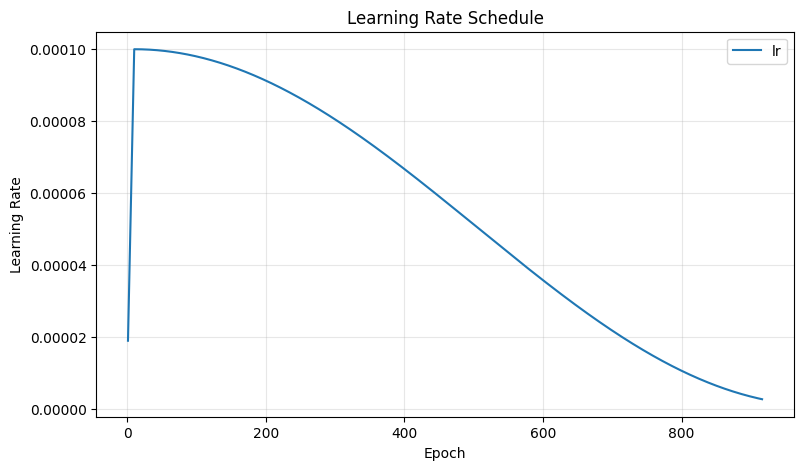

In [27]:
# =========================
# 5. 学习率曲线
# =========================

def plot_learning_rates(dataframe):
    lr_cols = []

    for c in dataframe.columns:
        low = c.lower()
        if low == "lr" or low.startswith("lr") or "learning_rate" in low:
            if pd.api.types.is_numeric_dtype(dataframe[c]):
                lr_cols.append(c)

    if not lr_cols:
        print("No numeric learning-rate columns found.")
        return

    plot_single_or_pair(
        dataframe,
        lr_cols,
        title="Learning Rate Schedule",
        ylabel="Learning Rate",
        filename="learning_rate"
    )

plot_learning_rates(df)


Train loss columns: ['train_loss', 'train_wbce_loss', 'train_dice_loss']
Validation loss columns: ['val_loss', 'val_wbce_loss', 'val_dice_loss']
Saved: runs/dinov3_vitl16_lora_woVI/vis/log_plots/loss_loss.png


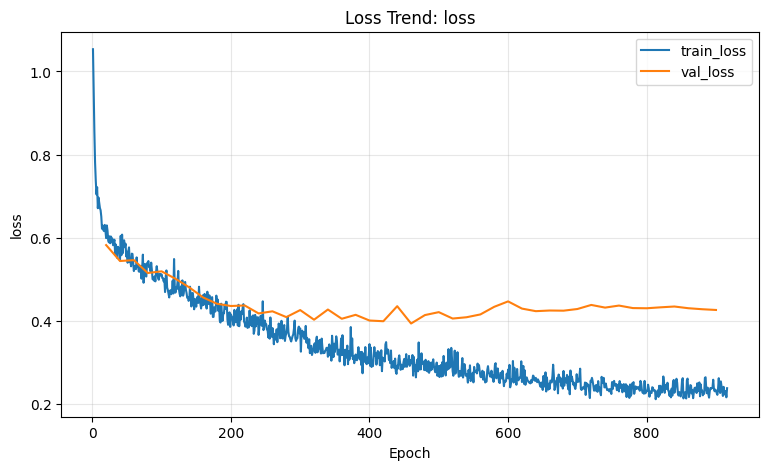

Saved: runs/dinov3_vitl16_lora_woVI/vis/log_plots/loss_wbce_loss.png


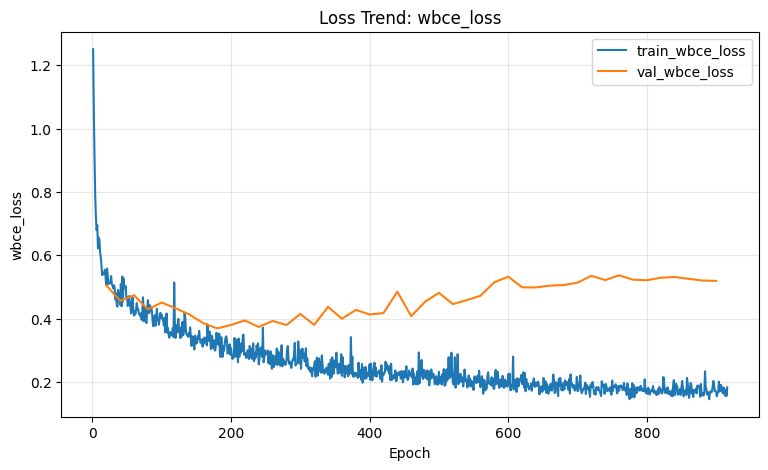

Saved: runs/dinov3_vitl16_lora_woVI/vis/log_plots/loss_dice_loss.png


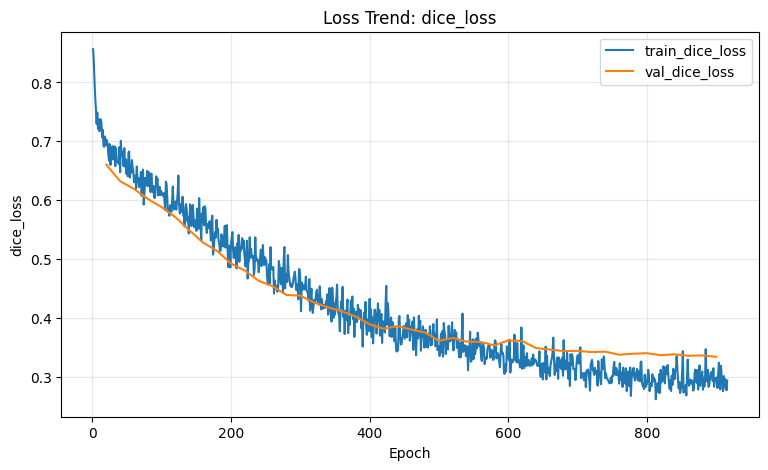

In [28]:
# =========================
# 6. Loss 曲线：自动识别所有 train_*loss / val_*loss
# =========================

train_losses, val_losses = infer_loss_columns(df)
all_loss_cols = train_losses + val_losses

print("Train loss columns:", train_losses)
print("Validation loss columns:", val_losses)

loss_pairs = pair_train_val_columns(all_loss_cols)

for base, pair in loss_pairs.items():
    cols = [c for c in [pair.get("train"), pair.get("val")] if c is not None]
    plot_single_or_pair(
        df,
        cols,
        title=f"Loss Trend: {base}",
        ylabel=base,
        filename=f"loss_{base}"
    )


Saved: runs/dinov3_vitl16_lora_woVI/vis/log_plots/train_loss_overview.png


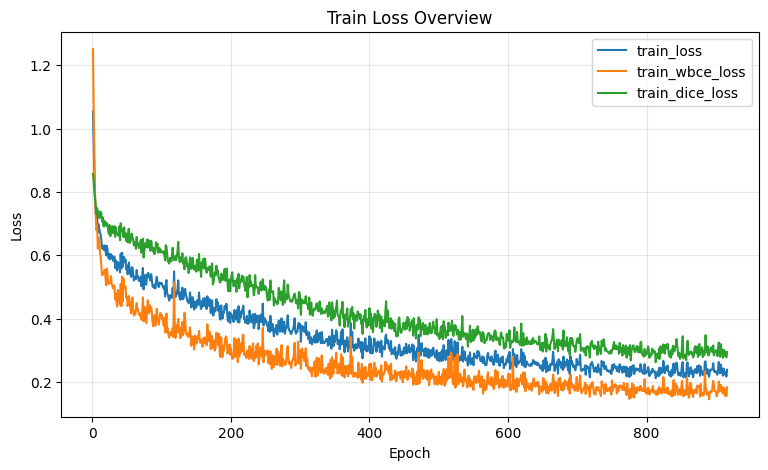

Saved: runs/dinov3_vitl16_lora_woVI/vis/log_plots/val_loss_overview.png


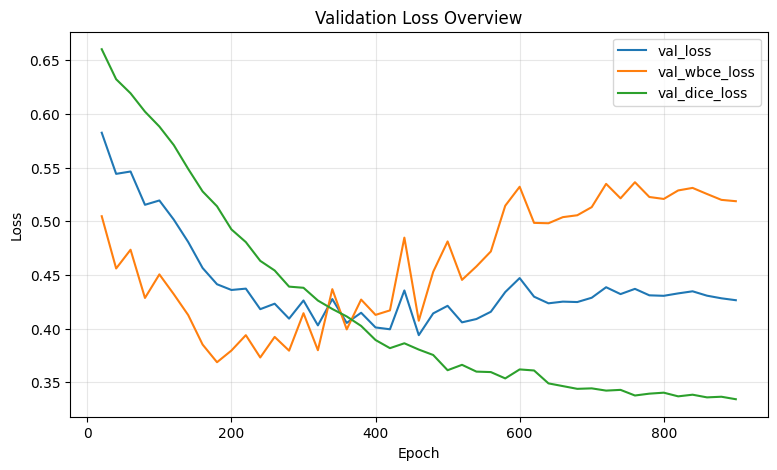

In [29]:
# =========================
# 7. Loss 总览图
# =========================

plot_single_or_pair(
    df,
    train_losses,
    title="Train Loss Overview",
    ylabel="Loss",
    filename="train_loss_overview"
)

plot_single_or_pair(
    df,
    val_losses,
    title="Validation Loss Overview",
    ylabel="Loss",
    filename="val_loss_overview"
)


Metric columns: ['train_iou', 'train_f1', 'train_precision', 'train_recall', 'train_accuracy', 'val_iou', 'val_f1', 'val_precision', 'val_recall', 'val_accuracy']
Saved: runs/dinov3_vitl16_lora_woVI/vis/log_plots/metric_iou.png


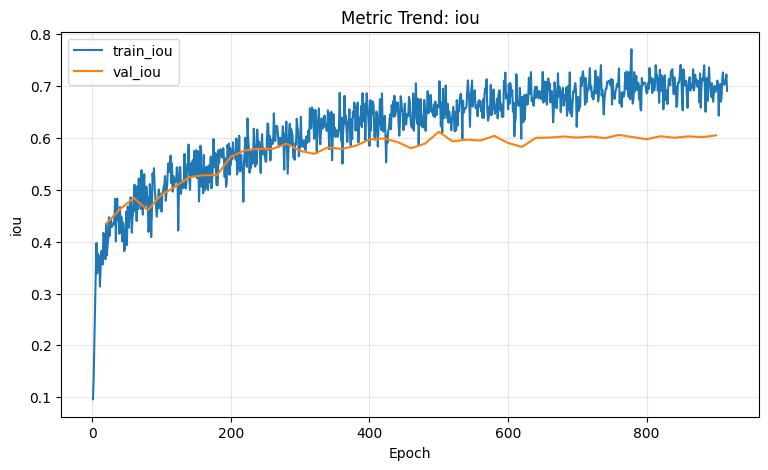

Saved: runs/dinov3_vitl16_lora_woVI/vis/log_plots/metric_f1.png


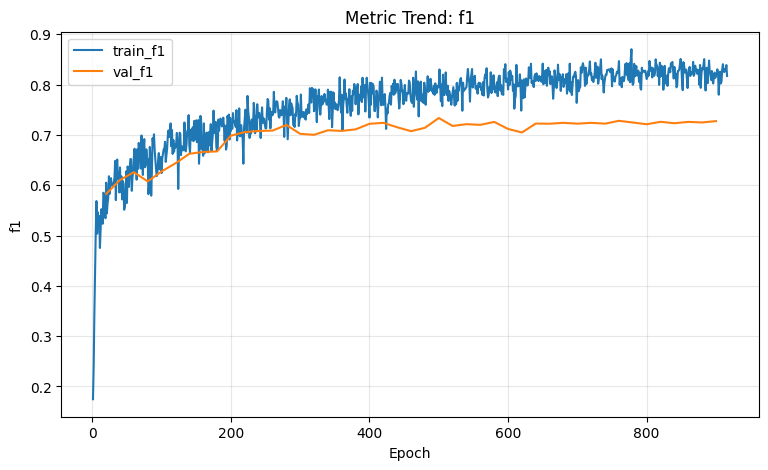

Saved: runs/dinov3_vitl16_lora_woVI/vis/log_plots/metric_precision.png


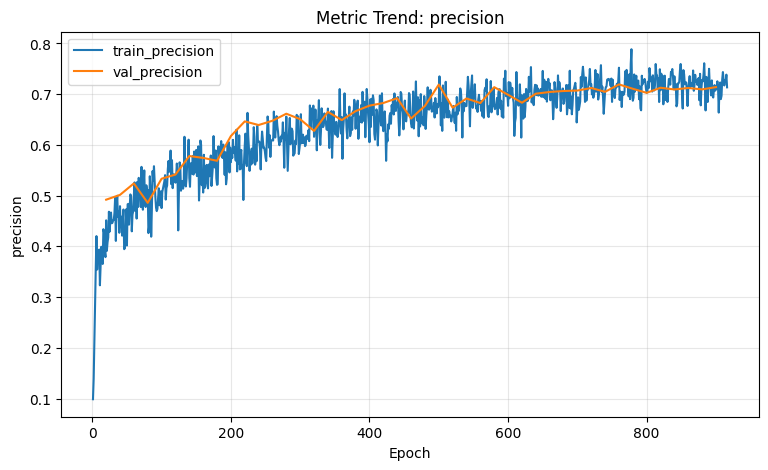

Saved: runs/dinov3_vitl16_lora_woVI/vis/log_plots/metric_recall.png


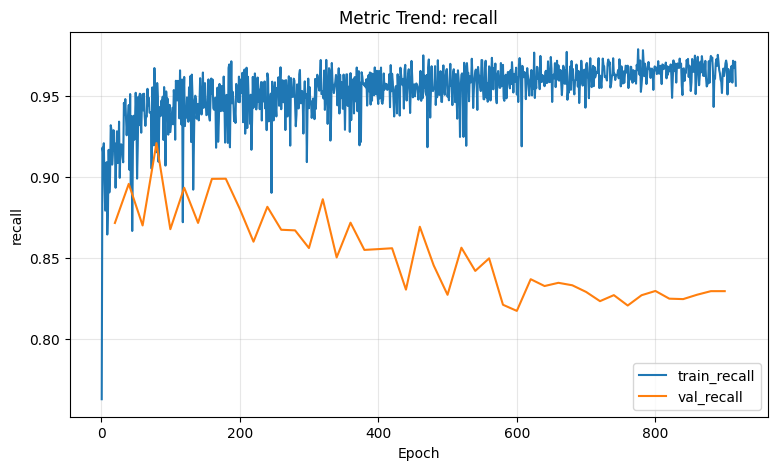

Saved: runs/dinov3_vitl16_lora_woVI/vis/log_plots/metric_accuracy.png


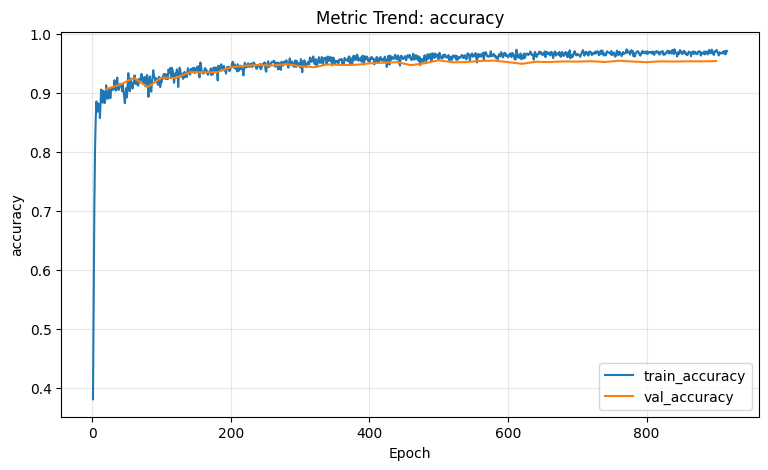

In [30]:
# =========================
# 8. Metric 曲线：自动识别 train_/val_ 的非 loss 数值列
# =========================

metric_cols = infer_metric_columns(df)
print("Metric columns:", metric_cols)

metric_pairs = pair_train_val_columns(metric_cols)

for base, pair in metric_pairs.items():
    cols = [c for c in [pair.get("train"), pair.get("val")] if c is not None]
    plot_single_or_pair(
        df,
        cols,
        title=f"Metric Trend: {base}",
        ylabel=base,
        filename=f"metric_{base}"
    )


Saved: runs/dinov3_vitl16_lora_woVI/vis/log_plots/preferred_iou.png


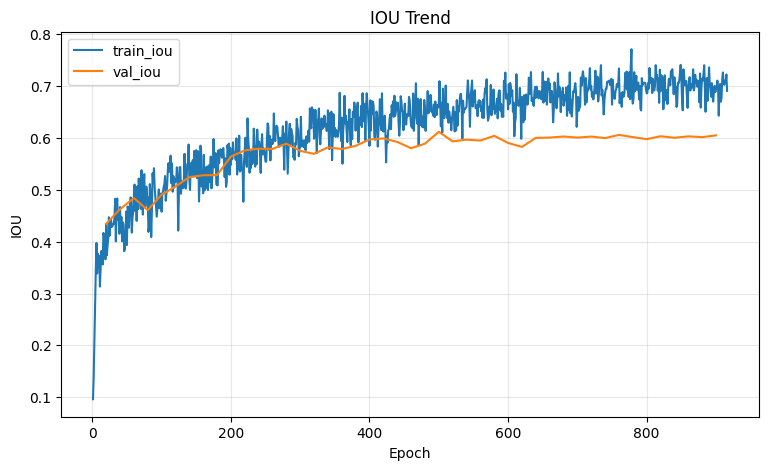

Saved: runs/dinov3_vitl16_lora_woVI/vis/log_plots/preferred_f1.png


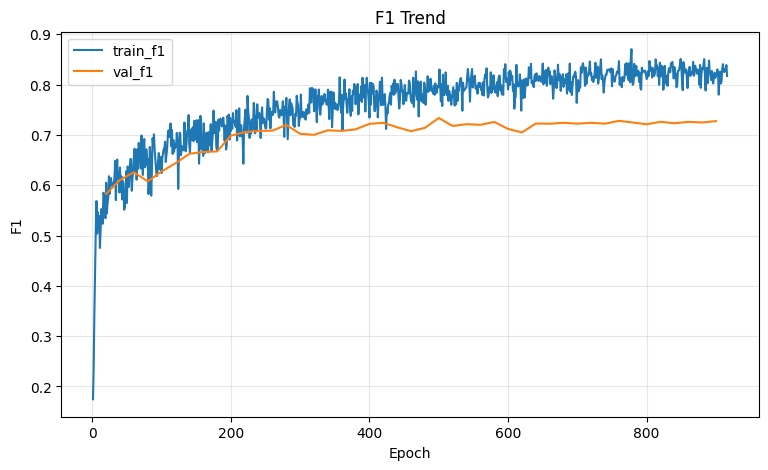

Saved: runs/dinov3_vitl16_lora_woVI/vis/log_plots/preferred_precision.png


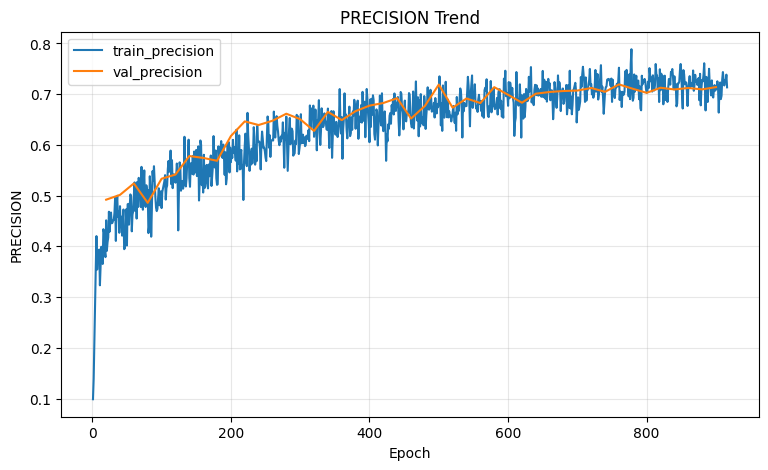

Saved: runs/dinov3_vitl16_lora_woVI/vis/log_plots/preferred_recall.png


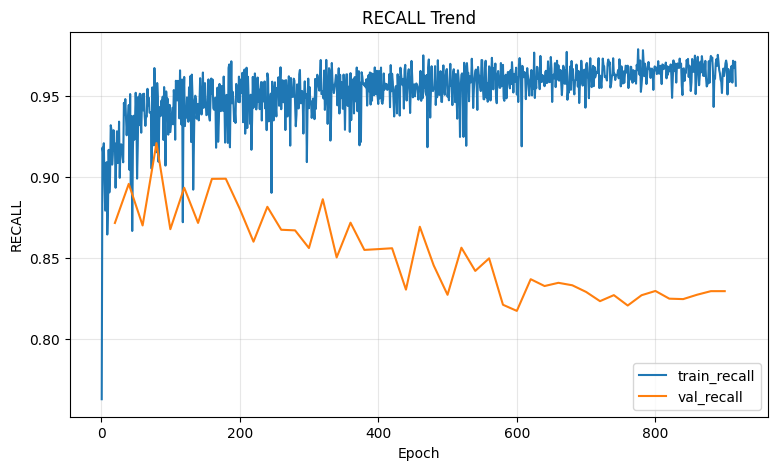

Saved: runs/dinov3_vitl16_lora_woVI/vis/log_plots/preferred_accuracy.png


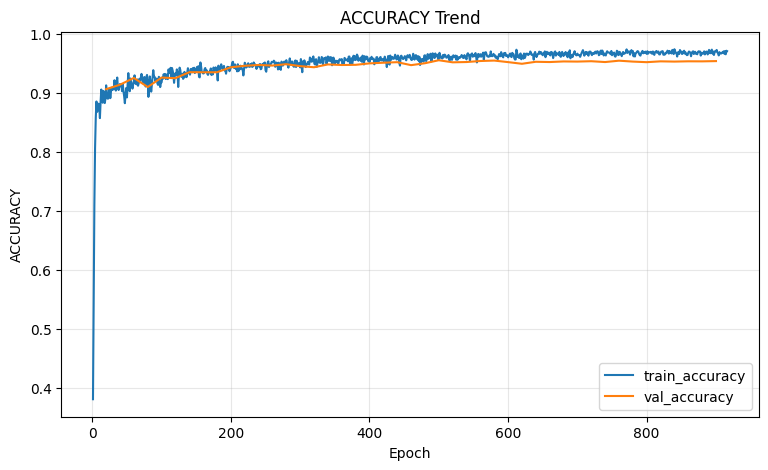

In [31]:
# =========================
# 9. 常用指标总览：IoU / F1 / Precision / Recall / Accuracy
# =========================

preferred_metrics = ["iou", "f1", "precision", "recall", "accuracy"]

for metric in preferred_metrics:
    cols = [
        c for c in df.columns
        if c.lower() in {f"train_{metric}", f"val_{metric}"}
        and pd.api.types.is_numeric_dtype(df[c])
    ]
    plot_single_or_pair(
        df,
        cols,
        title=f"{metric.upper()} Trend",
        ylabel=metric.upper(),
        filename=f"preferred_{metric}"
    )


In [32]:
# =========================
# 10. 最优 epoch 汇总
# =========================

def best_row_for_column(dataframe, col, mode):
    d = dataframe[["epoch", col]].copy()
    d[col] = pd.to_numeric(d[col], errors="coerce")
    d = d.dropna(subset=[col])
    if d.empty:
        return None

    idx = d[col].idxmin() if mode == "min" else d[col].idxmax()
    row = dataframe.loc[idx].copy()
    return {
        "column": col,
        "mode": mode,
        "best_epoch": int(row["epoch"]) if "epoch" in row else idx,
        "best_value": float(row[col]),
    }


summary = []

for col in all_loss_cols:
    item = best_row_for_column(df, col, mode="min")
    if item is not None:
        summary.append(item)

for col in metric_cols:
    item = best_row_for_column(df, col, mode="max")
    if item is not None:
        summary.append(item)

best_summary = pd.DataFrame(summary).sort_values(["column"])
display(best_summary)


,column,mode,best_epoch,best_value
10,train_accuracy,max,840,0.973882
2,train_dice_loss,min,813,0.262210
7,train_f1,max,778,0.870357
6,train_iou,max,778,0.771332
0,train_loss,min,813,0.211866
8,train_precision,max,778,0.788646
9,train_recall,max,775,0.978583
1,train_wbce_loss,min,890,0.145079
15,val_accuracy,max,500,0.955235
5,val_dice_loss,min,900,0.334255


In [33]:
# =========================
# 11. 验证集最优 checkpoint 建议
# =========================

candidate_priority = [
    "val_iou",
    "val_f1",
    "val_dice",
    "val_accuracy",
]

available_candidates = [
    c for c in candidate_priority
    if c in df.columns and pd.api.types.is_numeric_dtype(df[c])
]

if available_candidates:
    rows = []
    for col in available_candidates:
        d = df[["epoch", col]].dropna()
        if not d.empty:
            idx = d[col].idxmax()
            rows.append({
                "monitor": col,
                "best_epoch": int(df.loc[idx, "epoch"]),
                "best_value": float(df.loc[idx, col]),
            })
    display(pd.DataFrame(rows))
else:
    print("No common validation metric found. You can inspect best_summary above.")


,monitor,best_epoch,best_value
0,val_iou,500,0.612003
1,val_f1,500,0.733637
2,val_accuracy,500,0.955235


Saved: runs/dinov3_vitl16_lora_woVI/vis/log_plots/gap_iou.png


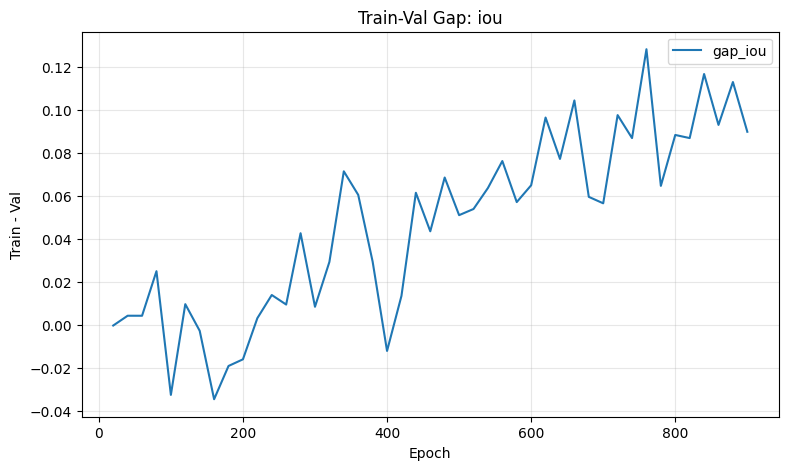

Saved: runs/dinov3_vitl16_lora_woVI/vis/log_plots/gap_f1.png


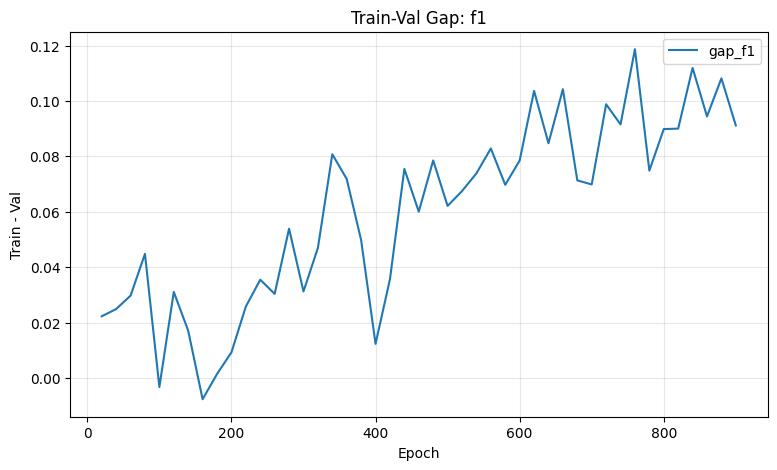

Saved: runs/dinov3_vitl16_lora_woVI/vis/log_plots/gap_precision.png


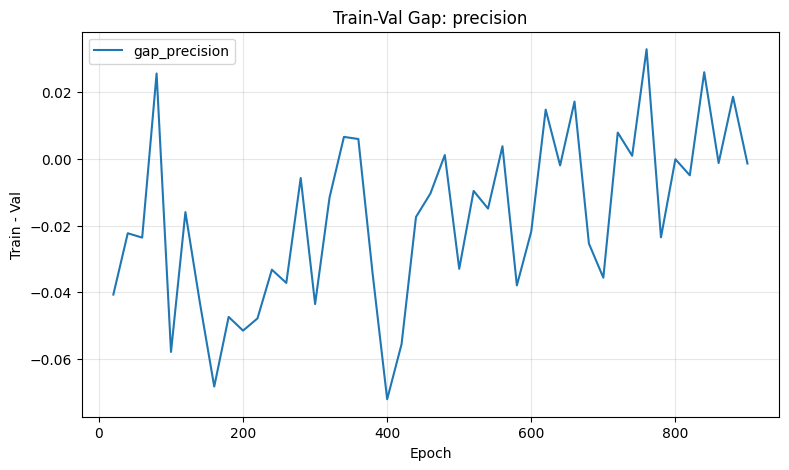

Saved: runs/dinov3_vitl16_lora_woVI/vis/log_plots/gap_recall.png


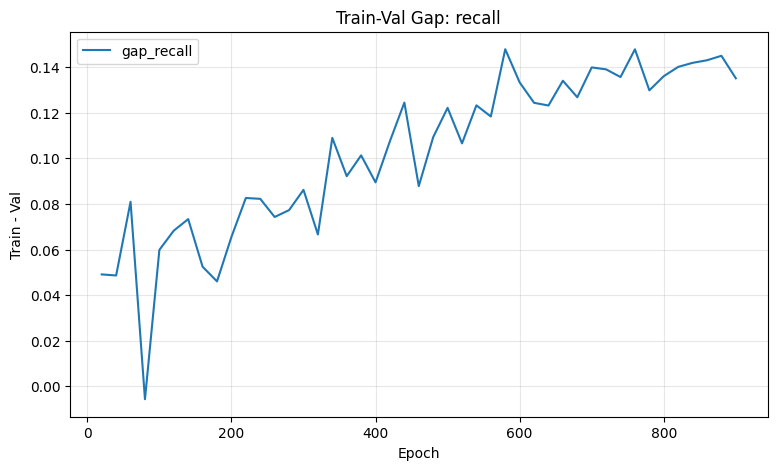

Saved: runs/dinov3_vitl16_lora_woVI/vis/log_plots/gap_accuracy.png


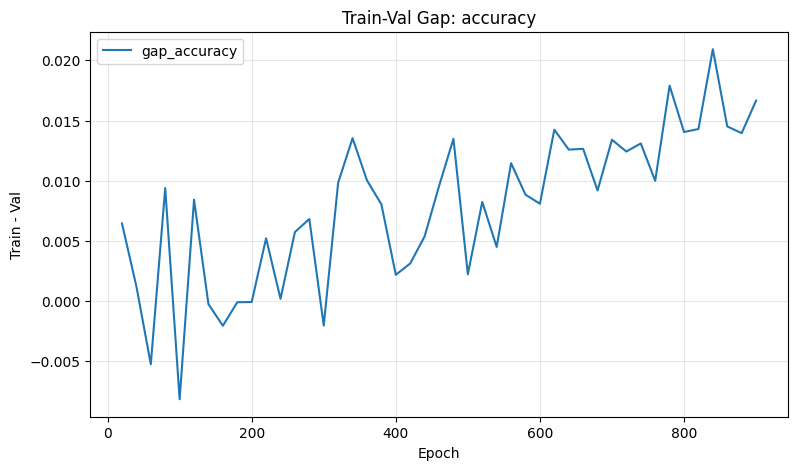

In [34]:
# =========================
# 12. Train-Val gap 分析
# =========================

gap_records = []
for base, pair in metric_pairs.items():
    train_col = pair.get("train")
    val_col = pair.get("val")
    if train_col is None or val_col is None:
        continue

    tmp = df[["epoch", train_col, val_col]].copy()
    tmp[train_col] = pd.to_numeric(tmp[train_col], errors="coerce")
    tmp[val_col] = pd.to_numeric(tmp[val_col], errors="coerce")
    tmp = tmp.dropna(subset=[train_col, val_col])

    if tmp.empty:
        continue

    gap_col = f"gap_{base}"
    df[gap_col] = df[train_col] - df[val_col]
    gap_records.append(gap_col)

for gap_col in gap_records:
    plot_single_or_pair(
        df,
        [gap_col],
        title=f"Train-Val Gap: {gap_col.replace('gap_', '')}",
        ylabel="Train - Val",
        filename=gap_col
    )


In [35]:
# =========================
# 13. 保存清洗后的 CSV 和最优汇总
# =========================

clean_csv_path = Path(OUTPUT_DIR) / "cleaned_log.csv"
best_summary_path = Path(OUTPUT_DIR) / "best_summary.csv"

df.to_csv(clean_csv_path, index=False)
best_summary.to_csv(best_summary_path, index=False)

print(f"Saved cleaned log: {clean_csv_path}")
print(f"Saved best summary: {best_summary_path}")
print(f"Saved figures to: {Path(OUTPUT_DIR).resolve()}")


Saved cleaned log: runs/dinov3_vitl16_lora_woVI/vis/log_plots/cleaned_log.csv
Saved best summary: runs/dinov3_vitl16_lora_woVI/vis/log_plots/best_summary.csv
Saved figures to: /home/wzk/Exp/My_model/runs/dinov3_vitl16_lora_woVI/vis/log_plots


## 使用建议

1. 只需要修改第一格的 `LOG_PATH`。
2. 新增 loss 时，只要列名包含 `loss` 且以 `train_` 或 `val_` 开头，就会自动画图。
   - 例如：`train_tversky_loss`, `val_tversky_loss`
   - 例如：`train_boundary_loss`, `val_boundary_loss`
3. 新增 metric 时，只要是 `train_` 或 `val_` 开头的数值列，并且不包含 `loss`，就会自动画图。
4. 如果验证集不是每个 epoch 都有，空值会自动跳过。
5. 如果曲线太抖，可以把 `SMOOTH_WINDOW` 改成 `5` 或 `10`。
